<a href="https://colab.research.google.com/github/aidandreyes/WNBA-DPOY-Predictor/blob/main/wnba_defense_09_19_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analyzing the Defensive DNA of the WNBA** by Aidan Reyes
## - **What statistics make a player the Defensive Player of the Year?**



---



In [ ]:
import requests
import pandas as pd

The data of this project comes from the official [WNBA website](https://stats.wnba.com/) and [Basketball Reference](https://www.basketball-reference.com/).

NOTE: The statistics are based on PER 100 POSSESSIONS to adjust for game pace and put players on a more equal scale in terms of playing time for comparison.

PER 100 POSSESSIONS = (Total Stat / Total # of Possessions) * 100

Sources:

- [2025 stats](https://stats.wnba.com/players/defense/?sort=PLAYER_NAME&dir=-1&Season=2025&SeasonType=Regular%20Season&PerMode=Per100Possessions)
- [2024 stats](https://stats.wnba.com/players/defense/?sort=PLAYER_NAME&dir=-1&Season=2024&SeasonType=Regular%20Season&PerMode=Per100Possessions)

- [2023 stats](https://stats.wnba.com/players/defense/?sort=PLAYER_NAME&dir=-1&Season=2023&SeasonType=Regular%20Season&PerMode=Per100Possessions)
- [2022 stats](https://stats.wnba.com/players/defense/?sort=PLAYER_NAME&dir=-1&Season=2022&SeasonType=Regular%20Season&PerMode=Per100Possessions)
- [2021 stats](https://stats.wnba.com/players/defense/?sort=PLAYER_NAME&dir=-1&Season=2021&SeasonType=Regular%20Season&PerMode=Per100Possessions)

The .csv files can be found in this [folder](https://drive.google.com/drive/folders/1YLAaPzbrMxmwE71M46i7hWFABBjPImdu?usp=drive_link).

NOTE FOR ME:

Create team defense stats .csv / dataframe for each season and merge by team, season
- https://stats.wnba.com/teams/defense/?sort=W&dir=-1&Season=2025&SeasonType=Regular%20Season&PerMode=Per100Possessions

Take defensive four factors (eFG%, TOV%, DRB%, FT/FGA), opponent shooting stats/per 100 possessions
- https://www.basketball-reference.com/wnba/years/2025.html



---

## **Loading Data**

In [ ]:
defense_2021 = pd.read_csv('/content/wnba_defense_2021.csv')
defense_2022 = pd.read_csv('/content/wnba_defense_2022.csv')
defense_2023 = pd.read_csv('/content/wnba_defense_2023.csv')
defense_2024 = pd.read_csv('/content/wnba_defense_2024.csv')
defense_2025 = pd.read_csv('/content/wnba_defense_2025.csv')

In [ ]:
# Combine into one dataframe
defense_df = pd.concat([defense_2021, defense_2022, defense_2023, defense_2024, defense_2025])


In [ ]:
# Add column into dataframe that indicates player won DPOY award
defense_df['dpoy_winner'] = 0
defense_df.head()

# Add column for DPOY winners
winners = {
    2021: ["Sylvia Fowles"],
    2022: ["A'ja Wilson"],
    2023: ["A'ja Wilson"],
    2024: ["Napheesa Collier"],
    2025: ["Alanna Smith", "A'ja Wilson"]
}

for winner in winners:
    player_names = winners[winner]
    for player_name in player_names:
        defense_df.loc[(defense_df['player'] == player_name) & (defense_df['season'] == winner), 'dpoy_winner'] = 1



---
## **Exploratory Data Analysis & Data Visualization**

## Defensive Rating of DPOY Winners

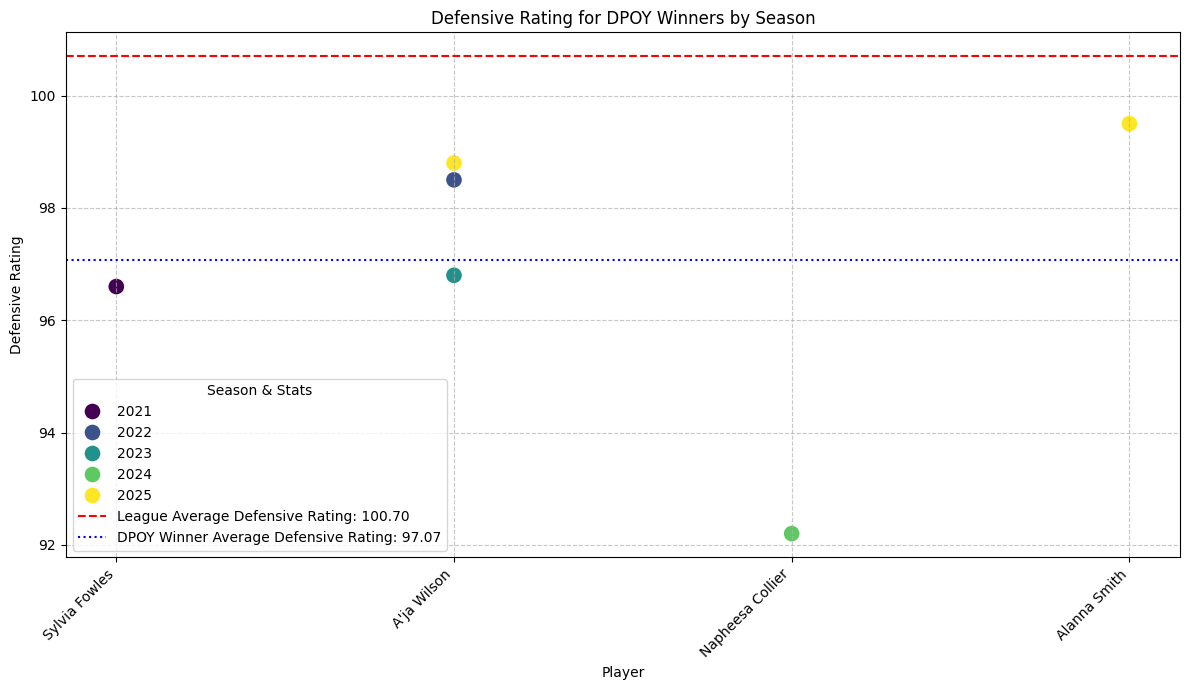

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

dpoy_winners_df = defense_df[defense_df['dpoy_winner'] == 1]

plt.figure(figsize=(12, 7))
sns.scatterplot(x='player', y='def_rtg', data=dpoy_winners_df, hue='season', s=150, palette='viridis', legend='full')
plt.title('Defensive Rating for DPOY Winners by Season')
plt.xlabel('Player')
plt.ylabel('Defensive Rating')
plt.xticks(rotation=45, ha='right')

# Calculate and add the mean def_rtg line for the entire league
mean_league_def_rtg = defense_df['def_rtg'].mean()
plt.axhline(y=mean_league_def_rtg, color='red', linestyle='--', label=f'League Average Defensive Rating: {mean_league_def_rtg:.2f}')

# Calculate and add the mean def_rtg line for DPOY winners
mean_dpoy_def_rtg = dpoy_winners_df['def_rtg'].mean()
plt.axhline(y=mean_dpoy_def_rtg, color='blue', linestyle=':', label=f'DPOY Winner Average Defensive Rating: {mean_dpoy_def_rtg:.2f}')

plt.legend(title='Season & Stats')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()